### 🎯 Gradient Boosting Regressor

Gradient Boosting là thuật toán học tăng cường (Boosting) sử dụng nhiều cây quyết định nhỏ (weak learners) được huấn luyện tuần tự, mỗi cây sửa lỗi của cây trước đó. 

- **Loss function**: Mean Squared Error (MSE)   
    -  Công thức: $\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$
    -  Trong đó:
        - $( n )$: Tổng số mẫu trong tập dữ liệu.
        - $( y_i )$: Giá trị thực tế (ground truth) của mẫu thứ $( i )$.
        - $( \hat{y}_i )$: Giá trị dự đoán của mô hình cho mẫu thứ $( i )$.
        - $( (y_i - \hat{y}_i) )$: Sai số (error) giữa giá trị thực tế và giá trị dự đoán.
        - $( (y_i - \hat{y}_i)^2 )$: Bình phương sai số, giúp loại bỏ dấu âm và nhấn mạnh các sai số lớn hơn.
- **Cơ chế học**: Gradient Descent – giảm dần lỗi dựa trên đạo hàm của hàm mất mát.

#### 🔧 Các siêu tham số quan trọng:
- `n_estimators`: Số lượng cây, càng nhiều thì mô hình càng mạnh (nhưng có thể overfit).
- `learning_rate`: Tốc độ học, càng nhỏ thì học chậm nhưng ổn định hơn.
- `max_depth`: Độ sâu của mỗi cây → kiểm soát độ phức tạp.
- `subsample`: Tỉ lệ dữ liệu sử dụng mỗi vòng → giúp chống overfitting.
- `min_samples_split` / `min_samples_leaf`: Điều kiện dừng chia nhánh → kiểm soát overfitting.


Phân phối dữ liệu tập train:
count    9.630000e+02
mean     9.719232e+06
std      7.761959e+06
min      7.500000e+05
25%      4.440000e+06
50%      7.090000e+06
75%      1.245000e+07
max      5.125000e+07
Name: price, dtype: float64
Phân phối dữ liệu tập test:
count    2.260000e+02
mean     1.061462e+07
std      8.494313e+06
min      1.750000e+06
25%      4.250000e+06
50%      7.970000e+06
75%      1.438500e+07
max      4.179000e+07
Name: price, dtype: float64
Encoding chip_model...
Encoding brand...
Encoding screen_tech...
Encoding screen_resolution_k...
Tuning hyperparameters...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100, subsample=0.6; total time=   0.2s
[CV] END learning_rate=0.001, max_depth=8, min_samples_leaf=5, min_samples_split=

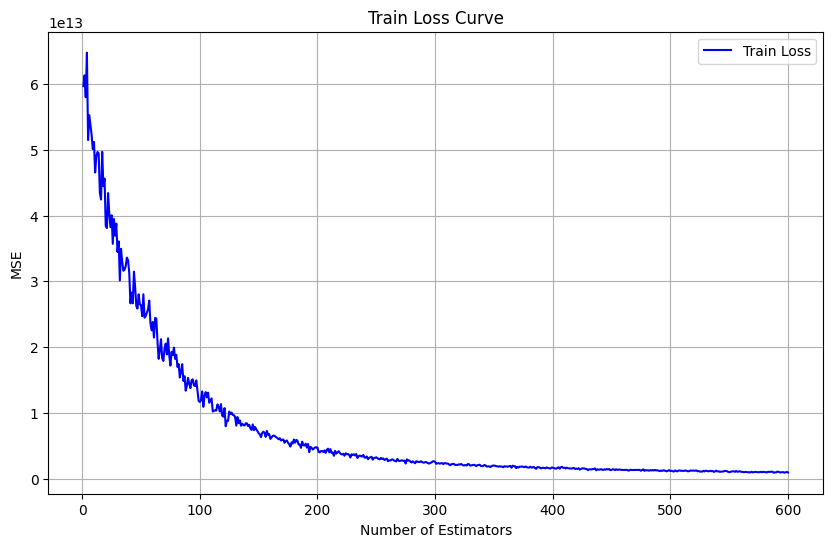

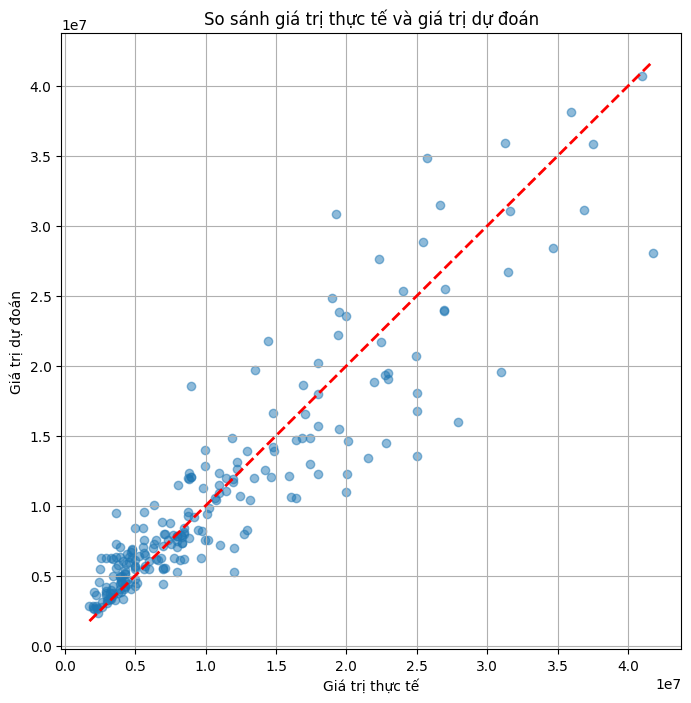

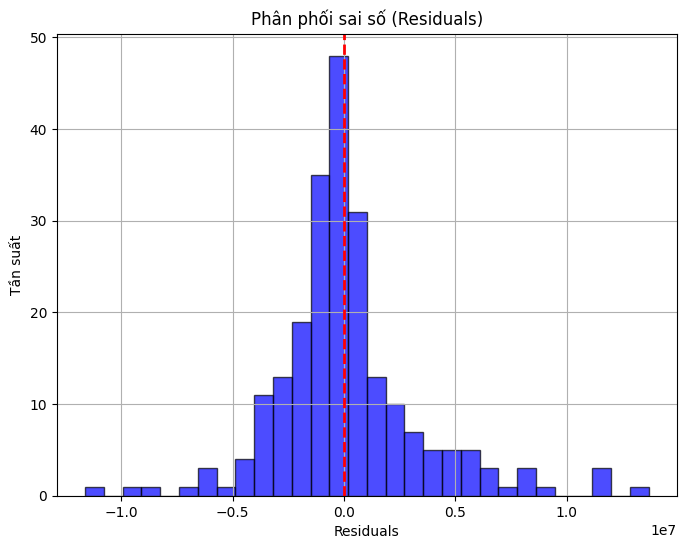

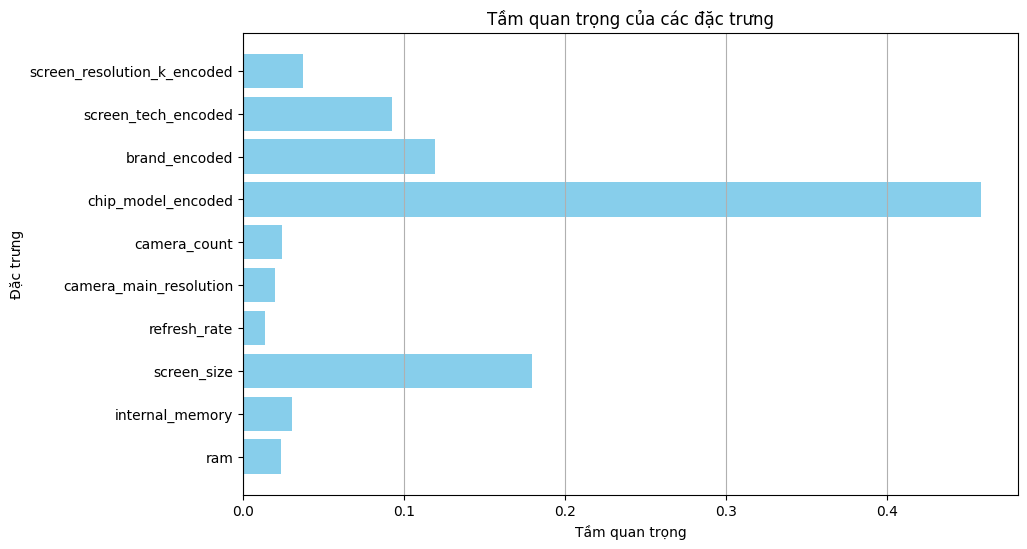

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
import json
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt

# Bước 1: Đọc dữ liệu
train_file = '../../data/datasets/train_stratified_by_chip_model.csv'
test_file = '../../data/datasets/test_stratified_by_chip_model.csv'

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Các cột cần encoding và cột mục tiêu
categorical_cols = ['chip_model', 'brand', 'screen_tech', 'screen_resolution_k']
target_col = 'price'

# Hiển thị phân phối dữ liệu
print("Phân phối dữ liệu tập train:")
print(train_df['price'].describe())

print("Phân phối dữ liệu tập test:")
print(test_df['price'].describe())

# Bước 2: Target Encoding
def target_encode_kfold(df, column, target, n_fold=5, alpha=10):
    df_copy = df.copy()
    global_mean = df_copy[target].mean()
    encoded = pd.Series(index=df_copy.index)
    kf = KFold(n_splits=n_fold, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(df_copy):
        means = df_copy.iloc[train_idx].groupby(column)[target].agg(['mean', 'count'])
        smoothed_means = ((means['mean'] * means['count']) + (global_mean * alpha)) / (means['count'] + alpha)
        encoded.iloc[test_idx] = df_copy.iloc[test_idx][column].map(smoothed_means)

    encoded.fillna(global_mean, inplace=True)
    return encoded

# Áp dụng Target Encoding
encoding_means = {}
for col in categorical_cols:
    print(f"Encoding {col}...")
    train_df[f'{col}_encoded'] = target_encode_kfold(train_df, column=col, target=target_col)
    encoding_means[col] = train_df.groupby(col)[f'{col}_encoded'].mean().to_dict()

# Áp dụng encoding cho tập test
for col in categorical_cols:
    test_df[f'{col}_encoded'] = test_df[col].map(encoding_means[col]).fillna(train_df[target_col].mean())
    
# Bước 3: Chuẩn bị dữ liệu
features = ['ram', 'internal_memory', 'screen_size', 'refresh_rate', 
            'camera_main_resolution', 'camera_count', 'chip_model_encoded', 
            'brand_encoded', 'screen_tech_encoded', 'screen_resolution_k_encoded']
X_train = train_df[features]
y_train = train_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

# Bước 4: Tối ưu hóa siêu tham số
param_dist = {
    'n_estimators': [100, 300, 500, 600, 800],
    'learning_rate': [0.01, 0.005, 0.001],
    'max_depth': [3, 5, 6, 8],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    random_state=42
)

print("Tuning hyperparameters...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print("✅ Best Hyperparameters:")
print(random_search.best_params_)

# Bước 5: Đánh giá mô hình
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")


# Lưu model tốt nhất
print("Saving best model...")
joblib.dump(best_model, 'best_gb_model.pkl')
print("✅ Saved best model to 'best_gb_model.pkl'")

# Bước 7: Trực quan hóa loss trên tập train
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(best_model.train_score_) + 1), best_model.train_score_, label='Train Loss', color='blue')
plt.xlabel('Number of Estimators')
plt.ylabel('MSE')
plt.title('Train Loss Curve')
plt.legend()
plt.grid()
plt.show()


# Biểu đồ scatter giữa giá trị thực tế và giá trị dự đoán
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế')
plt.ylabel('Giá trị dự đoán')
plt.title('So sánh giá trị thực tế và giá trị dự đoán')
plt.grid()
plt.show()

# Biểu đồ phân phối sai số (Residual Plot)
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Tần suất')
plt.title('Phân phối sai số (Residuals)')
plt.grid()
plt.show()

# Biểu đồ tầm quan trọng của đặc trưng
feature_importances = best_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel('Tầm quan trọng')
plt.ylabel('Đặc trưng')
plt.title('Tầm quan trọng của các đặc trưng')
plt.grid(axis='x')
plt.show()